# 1. Imports

In [8]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
%matplotlib inline

# 2. Load the prepared data

Shape: (4819, 11)

Target distribution:
student_status
2    47.4
0    32.2
1    20.5
Name: proportion, dtype: float64 %


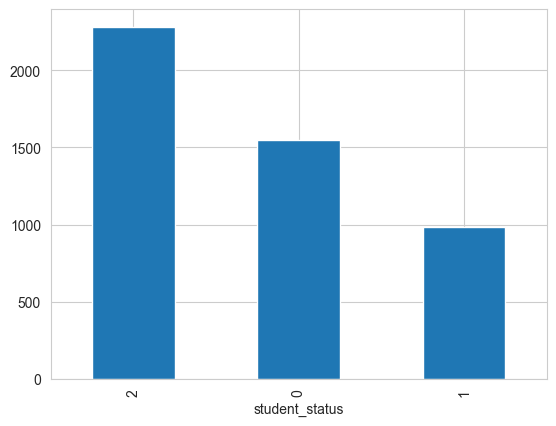

In [10]:

df = pd.read_csv("data/output/training_data.csv")

print("Shape:", df.shape)
print("\nTarget distribution:")
print(df["student_status"].value_counts(normalize=True).round(3) * 100, "%")
df["student_status"].value_counts().plot(kind="bar")

# Features & target
X = df.drop("student_status", axis=1)
y = df["student_status"]




# 3. Train-test Split

In [19]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.15,
    stratify=y,
    random_state=42
)


X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.17647,          
    stratify=y_temp,
    random_state=42
)



print(f"Full dataset:     {len(df):4d} rows")
print(f"Train:            {len(X_train):4d} rows ({len(X_train)/len(df)*100:.1f}%)")
print(f"Validation:       {len(X_val):4d} rows  ({len(X_val)/len(df)*100:.1f}%)")
print(f"Test:  {len(X_test):4d} rows  ({len(X_test)/len(df)*100:.1f}%)")
print()

print("Train class distribution (%):")
print(y_train.value_counts(normalize=True).sort_index().round(4) * 100)
print("\nVal class distribution (%):")
print(y_val.value_counts(normalize=True).sort_index().round(4) * 100)
print("\nTest class distribution (%):")
print(y_test.value_counts(normalize=True).sort_index().round(4) * 100)



Full dataset:     4819 rows
Train:            3373 rows (70.0%)
Validation:        723 rows  (15.0%)
Test:   723 rows  (15.0%)

Train class distribution (%):
student_status
0    32.17
1    20.46
2    47.38
Name: proportion, dtype: float64

Val class distribution (%):
student_status
0    32.23
1    20.47
2    47.30
Name: proportion, dtype: float64

Test class distribution (%):
student_status
0    32.23
1    20.47
2    47.30
Name: proportion, dtype: float64


# 4. Baseline Modeling

### A. Logistic Regression

c:\Users\ADMIN\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



=== Logistic Regression on Test Set ===
Accuracy: 0.7026

Classification Report:
              precision    recall  f1-score   support

     Dropout     0.8010    0.6910    0.7419       233
    Enrolled     0.3784    0.4730    0.4204       148
    Graduate     0.8220    0.8099    0.8159       342

    accuracy                         0.7026       723
   macro avg     0.6671    0.6580    0.6594       723
weighted avg     0.7244    0.7026    0.7111       723



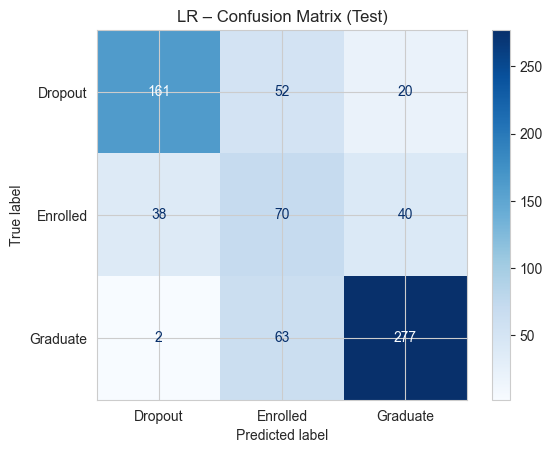

In [20]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    multi_class="multinomial",
    solver="lbfgs",
    max_iter=1500,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

lr.fit(X_train, y_train)

y_pred_lr_test = lr.predict(X_test)

print("\n=== Logistic Regression on Test Set ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr_test):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr_test, 
                            target_names=["Dropout", "Enrolled", "Graduate"], 
                            digits=4))

# Confusion Matrix (test set)
cm_lr = confusion_matrix(y_test, y_pred_lr_test)
disp = ConfusionMatrixDisplay(cm_lr, display_labels=["Dropout", "Enrolled", "Graduate"])
disp.plot(cmap="Blues")
plt.title("LR – Confusion Matrix (Test)")
plt.show()

### B. Random Forest


=== Random Forest on Test Set ===
Accuracy: 0.7165

Classification Report:
              precision    recall  f1-score   support

     Dropout     0.7511    0.7253    0.7380       233
    Enrolled     0.4557    0.4865    0.4706       148
    Graduate     0.8147    0.8099    0.8123       342

    accuracy                         0.7165       723
   macro avg     0.6738    0.6739    0.6736       723
weighted avg     0.7207    0.7165    0.7184       723



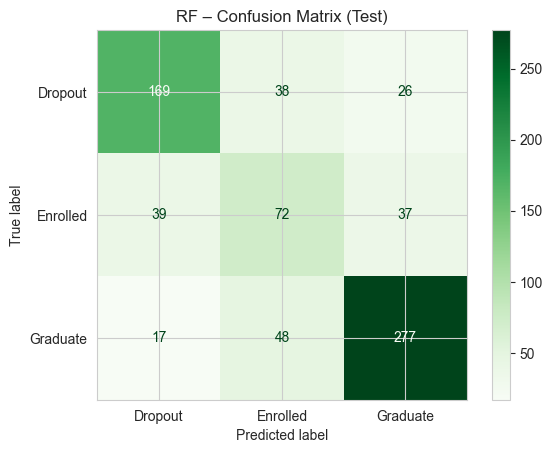

In [21]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_split=4,
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight="balanced_subsample",   # slightly better than plain "balanced" for RF
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_rf_test = rf.predict(X_test)

print("\n=== Random Forest on Test Set ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf_test):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf_test, 
                            target_names=["Dropout", "Enrolled", "Graduate"], 
                            digits=4))

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf_test)
disp = ConfusionMatrixDisplay(cm_rf, display_labels=["Dropout", "Enrolled", "Graduate"])
disp.plot(cmap="Greens")
plt.title("RF – Confusion Matrix (Test)")
plt.show()


=== Baseline Models Comparison (Test Set) ===


,Accuracy,Macro F1,Weighted F1,Dropout F1,Enrolled F1,Graduate F1
Model,,,,,,
Logistic Regression,0.7026,0.6594,0.7111,0.7419,0.4204,0.8159
Random Forest,0.7165,0.6736,0.7184,0.7380,0.4706,0.8123


<Figure size 1000x600 with 0 Axes>

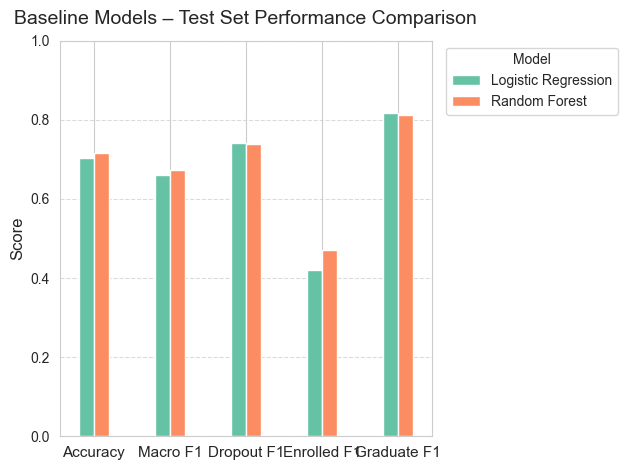

In [23]:
# ────────────────────────────────────────────────
# Compare Baseline Models side-by-side
# ────────────────────────────────────────────────
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

results = {
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [0.7026, 0.7165],
    'Macro F1': [0.6594, 0.6736],
    'Weighted F1': [0.7111, 0.7184],
    'Dropout F1': [0.7419, 0.7380],
    'Enrolled F1': [0.4204, 0.4706],
    'Graduate F1': [0.8159, 0.8123]
}

df_compare = pd.DataFrame(results).round(4)
df_compare.set_index('Model', inplace=True)

print("\n=== Baseline Models Comparison (Test Set) ===")
display(df_compare)


metrics_to_plot = ['Accuracy', 'Macro F1', 'Dropout F1', 'Enrolled F1', 'Graduate F1']
df_plot = df_compare[metrics_to_plot].T

plt.figure(figsize=(10, 6))
df_plot.plot(kind='bar', width=0.4, color=['#66c2a5', '#fc8d62'])
plt.title('Baseline Models – Test Set Performance Comparison', fontsize=14, pad=12)
plt.ylabel('Score', fontsize=12)
plt.ylim(0, 1)
plt.xticks(rotation=0, fontsize=11)
plt.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()



## Baseline Models – Test Set Results (723 samples)

**Dataset split**: 70% train / 15% validation / 15% test

**Class distribution in test set**:
- Dropout (0)    : 233 (~32.2%)
- Enrolled (1)   : 148 (~20.5%)
- Graduate (2)   : 342 (~47.3%)

### Logistic Regression
- Accuracy: **0.7026**
- Macro F1: **0.6594**
- Weighted F1: **0.7111**

Per-class performance:
- Dropout   → F1 = 0.7419 (precision 0.8010, recall 0.6910)
- Enrolled  → F1 = 0.4204 (lowest – hardest class)
- Graduate  → F1 = 0.8159

### Random Forest
- Accuracy: **0.7165** (+1.4% over LR)
- Macro F1: **0.6736** (+0.014 over LR)
- Weighted F1: **0.7184**

Per-class performance:
- Dropout   → F1 = 0.7380
- Enrolled  → F1 = 0.4706 (still low, but +0.05 improvement)
- Graduate  → F1 = 0.8123

**Key observations**:
- Random Forest slightly outperforms Logistic Regression overall.
- Enrolled class remains the most difficult to predict.
- Dropout detection is reasonably strong (F1 ~0.74).
- Graduate prediction is solid (F1 ~0.81–0.82).


**Next**: Use the same splits for the deep learning model and compare final test metrics.